In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from qubic.lib.Qdictionary import qubicDict
from qubic.lib.Instrument.Qacquisition import QubicMultiAcquisitions
from qubic.lib.Qsamplings import get_pointing, equ2gal
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel
from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator
from qubic.lib.QskySim import get_angular_profile
import gc
%matplotlib inline

In [2]:
nside = 256

# Test Coverage

In [3]:
# Build MPI communicator and qubic dict
dictfilename = 'qubic/qubic/dicts/pipeline_demo.dict'
d = qubicDict()
d.read_from_file(dictfilename)

center = equ2gal(d['RA_center'], d['DEC_center'])

d['nf_recon'] = 2
d['MultiBand'] = True
d['nside'] = nside

d['npointings'] = 20
d['synthbeam_kmax'] = 1
nf_sub = d['nf_sub']
d['synthbeam_fraction'] = 1

d['noiseless'] = True
d['photon_noise'] = False
d['use_synthbeam_fits_file'] = False

In [4]:
d["interp_projection"] = False

# Npointings

In [5]:
N = 10
npointings_list = np.logspace(np.log(20), np.log(75), N, dtype=int)
print(npointings_list)

[  990  1388  1947  2730  3829  5370  7531 10562 14812 20772]


In [6]:
cov_list = []

for npointings in npointings_list:
    d["npointings"] = npointings
    acq = QubicMultiAcquisitions(d, nsub=2, nrec=2)
    cov = acq._get_coverage()
    cov = np.ones((cov.shape[0], 3)) * cov[:, None]
    
    cov_list.append(cov)
    
    del(acq)
    del(cov)
    gc.collect()

Info arch-laptop: Allocating (982080,9) elements = 134.8681640625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (982080,9) elements = 134.8681640625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (1376896,9) elements = 189.087890625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (1376896,9) elements = 189.087890625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (1931424,9) elements = 265.24072265625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (1931424,9) elements = 265.24072265625 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (2708160,9) elements = 371.9091796875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (2708160,9) elements = 371.9091796875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (3798368,9) elements = 521.62646484375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (3798368,9) elements = 521.626464843

(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)
(20,) (20,) (20,)


Text(0.5, 1.0, 'Normalised coverage RMS')

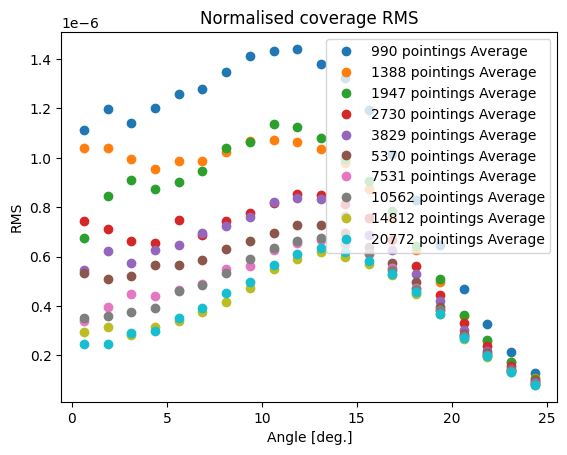

In [7]:
for i, cov in enumerate(cov_list):
    get_angular_profile(cov/cov.sum(), doplot=True, nbins=20, label=f"{npointings_list[i]} pointings")
plt.title("Normalised coverage RMS")